You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [13]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# Directories
PROJECT_DIR = os.path.dirname(os.getcwd())      # Retrieve current directory and go one level up
                                                # If the notebook is at the root directory, please remove os.path.dirname(...)
PROJECT_DIR = PROJECT_DIR[1:]                   # Removed "/" at index 0 for clarity

# Directories
DATA_DIR = "data"
RAW_DATA_DIR = f"{PROJECT_DIR}/{DATA_DIR}/raw"
IMAGE_DIR = f"{RAW_DATA_DIR}/crops/Crop_224_5fp_100K"

# Files
DF_TRAIN = f"/{RAW_DATA_DIR}/train.csv"
DF_TEST = f"/{RAW_DATA_DIR}/test_students.csv"
IMAGE_TEST = f"/{IMAGE_DIR}/database1/img00000048.webp"

files = [DF_TRAIN,
         DF_TEST,
         IMAGE_TEST]

for file in files:
    if os.path.exists(file):
        print(f"File O.k.! :\t{file}")
    else:
        print(f"File NOT O.k.! : {file}")

File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/train.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/test_students.csv
File O.k.! :	/home/mambo/Documents/data-challenge-idemia/data/raw/crops/Crop_224_5fp_100K/database1/img00000048.webp


### Load dataframes

In [14]:
df_train = pd.read_csv(DF_TRAIN, delimiter=',')
df_test = pd.read_csv(DF_TEST, delimiter=',')

image_dir = "crops/Crop_224_5fp_100K"

In [15]:
row = df_train.loc[1]
filename = row['filename']
print(filename)

df_train.info()
print(df_train.describe())
df_train.head()

database3/database3/m.016ywr/88-FaceId-0_align.webp
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   filename       100000 non-null  str    
 1   FaceOcclusion  100000 non-null  float64
 2   gender         100000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 2.3 MB
       FaceOcclusion         gender
count  100000.000000  100000.000000
mean        0.082720       0.676000
std         0.086538       0.468002
min         0.000000       0.000000
25%         0.017928       0.000000
50%         0.049661       1.000000
75%         0.122675       1.000000
max         1.000000       1.000000


,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [16]:
df_test.info()
print(df_test.describe())
df_test.head()

<class 'pandas.DataFrame'>
RangeIndex: 29980 entries, 0 to 29979
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   filename  29980 non-null  str  
dtypes: str(1)
memory usage: 234.3 KB
                                                 filename
count                                               29980
unique                                              29980
top     database3/database3/m.0256vn/81-FaceId-0_align...
freq                                                    1


,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [17]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [18]:
df_val = df_train.iloc[:20000].reset_index(drop = True)
df_train = df_train.iloc[20000:].reset_index(drop = True)

df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.02740n/28-FaceId-0_align...,0.270369,0.0
1,database3/database3/m.01l9c3z/24-FaceId-0_alig...,0.041362,1.0
2,database3/database3/m.02grkt/29-FaceId-0_align...,0.011829,0.0
3,database3/database3/m.0294fd/58-FaceId-0_align...,0.170409,0.0
4,database3/database3/m.0264yjz/104-FaceId-0_ali...,0.000000,1.0


In [19]:
len(df_train), len(df_val), len(df_test)

(80000, 20000, 29980)

In [20]:
print(type(range(5)))
from time import sleep

with tqdm(total=100) as pbar:
    for i in range(10):
        sleep(0.1)
        pbar.update(10)

<class 'range'>


100%|██████████| 100/100 [00:01<00:00, 99.22it/s]


### Check that all images are read correctly

In [ ]:
#-------------------------
# Train data
#-------------------------
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        print(filename)
        img2display = Image.open(f"/{IMAGE_DIR}/{filename}")
    except ValueError as e:
        print(idx, e)
        
#-------------------------
# Validation data
#-------------------------
for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"/{IMAGE_DIR}/{filename}")
    except ValueError as e:
        print(idx, e)

#-------------------------
# Test data
#-------------------------
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"/{IMAGE_DIR}/{filename}")
    except ValueError as e:
        print(idx, e)      

### Display random images

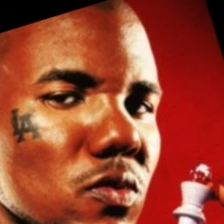

database3/database3/m.01vwd7x/52-FaceId-0_align.webp 0.0 1.0


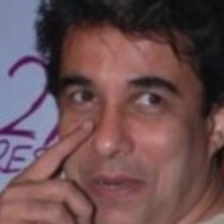

database3/database3/m.027gsx3/67-FaceId-0_align.webp 0.133318 1.0


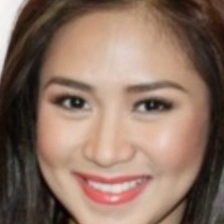

database3/database3/m.01qkb5j/111-FaceId-0_align.webp 0.05864 0.0


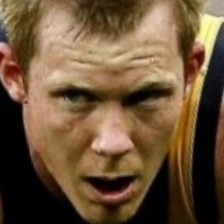

database3/database3/m.0270n1w/72-FaceId-0_align.webp 0.06713 1.0


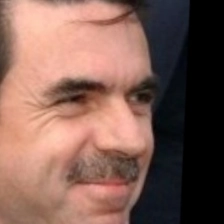

database3/database3/m.01c29s/73-FaceId-0_align.webp 0.003877 1.0


In [21]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"/{IMAGE_DIR}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [22]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"/{self.image_dir}/{filename}")

        # Converts image into a PyTorch tensor
        X = self.transform(img)

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename
    print(IMAGE_DIR)

home/mambo/Documents/data-challenge-idemia/data/raw/crops/Crop_224_5fp_100K


In [23]:
training_set = Dataset(df_train, IMAGE_DIR)
validation_set = Dataset(df_val, IMAGE_DIR)
test_set = Dataset(df_test, IMAGE_DIR, training=False)

In [24]:
params_train = {'batch_size': 64,
          'shuffle': True,
          'num_workers': 4}

params_val = {'batch_size': 64,
          'shuffle': False,
          'num_workers': 4}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

### Create naive model

In [102]:
from torchvision.models import mobilenet_v3_small
model = torchvision.models.mobilenet_v3_small(num_classes=1)
model

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16

#### Count number of parameters

In [103]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_trainable_params = 0
    total_params = 0
    for name, parameter in model.named_parameters():
        params = parameter.numel()
        total_params += params
        if not parameter.requires_grad:
            continue
        table.add_row([name, params])
        total_trainable_params += params
    print(table)
    print(f"Total Trainable Params: {total_trainable_params}")
    print(f"Total Params: {total_params}")
    
count_parameters(model)

+--------------------------------+------------+
|            Modules             | Parameters |
+--------------------------------+------------+
|      features.0.0.weight       |    432     |
|      features.0.1.weight       |     16     |
|       features.0.1.bias        |     16     |
|  features.1.block.0.0.weight   |    144     |
|  features.1.block.0.1.weight   |     16     |
|   features.1.block.0.1.bias    |     16     |
| features.1.block.1.fc1.weight  |    128     |
|  features.1.block.1.fc1.bias   |     8      |
| features.1.block.1.fc2.weight  |    128     |
|  features.1.block.1.fc2.bias   |     16     |
|  features.1.block.2.0.weight   |    256     |
|  features.1.block.2.1.weight   |     16     |
|   features.1.block.2.1.bias    |     16     |
|  features.2.block.0.0.weight   |    1152    |
|  features.2.block.0.1.weight   |     72     |
|   features.2.block.0.1.bias    |     72     |
|  features.2.block.1.0.weight   |    648     |
|  features.2.block.1.1.weight   |     7

### Loss and optimizer

In [104]:
loss_fn = nn.MSELoss()

In [105]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train naive model

In [106]:
# CUDA for PyTorch
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True

model = model.to(device)



#### Fit on train split

In [107]:
num_epochs = 1

for n in range(num_epochs):
    print(f"Epoch {n+1}")
    for batch_idx, (X, y, gender, filename) in (pbar := tqdm(enumerate(training_generator), total=len(training_generator))):
        # Transfer to GPU
        X, y = X.to(device), y.to(device)
        y = y.view(-1, 1)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        if loss.isnan():
            print(filename)
            print('label', y)
            print('y_pred', y_pred)
            break

        pbar.set_description(f"Loss: {loss.item():.4f}")
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

Epoch 1


Loss: 0.0134:   1%|          | 11/1250 [01:04<52:48,  2.56s/it]  Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x705291d0f880>
Traceback (most recent call last):
  File "/home/mambo/Documents/data-challenge-idemia/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1686, in __del__
    self._shutdown_workers()
  File "/home/mambo/Documents/data-challenge-idemia/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1669, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Loss: 0.0133:   1%|          | 11/1250 [01:04<52:48,  2.56s/it]AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x705291d0f880>
Traceback (most recent call last):
  File "/home/

## Evaluate metric on validation split

In [108]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [109]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        for i in range(len(X)):

            results_list.append({'filename': filename[i],
                                 'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i])
                                 })
results_df = pd.DataFrame(results_list)

100%|██████████| 313/313 [00:12<00:00, 25.93it/s]


In [110]:
results_df.head()

,filename,pred,target,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.032344,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.026713,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.037619,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.197478,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.204490,0.252091,1.0


<Axes: >

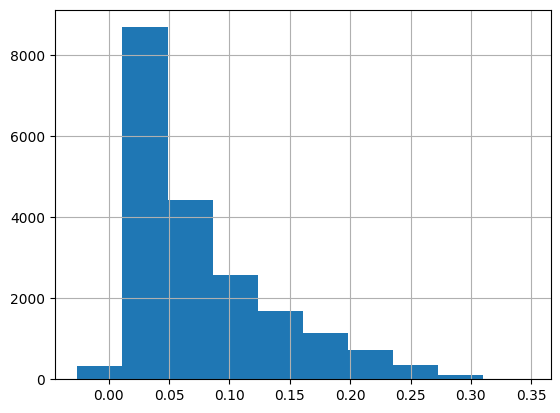

In [111]:
import matplotlib.pyplot as plt
results_df['pred'].hist()


In [112]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [113]:
metric_fn(results_male, results_female)

np.float64(0.005392551936748935)

### Make predictions on test dataset

In [114]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        X = X.to(device)
        y_pred = model(X)
    
        for i in range(len(X)):
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred[i]),
                                 })
results_df = pd.DataFrame(results_list)

100%|██████████| 469/469 [00:18<00:00, 25.79it/s]


In [115]:
results_df.head()

,filename,FaceOcclusion
0,database3/database3/m.0256vn/81-FaceId-0_align...,0.121096
1,database3/database3/m.01dgwg/29-FaceId-0_align...,0.102063
2,database3/database3/m.02l0nk/72-FaceId-0_align...,0.063325
3,database3/database3/m.026jp3/94-FaceId-1_align...,0.108786
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...,0.052292


### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [116]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)